Stock Prediciton

In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#Load the csv file
df = pd.read_csv("TCS_Dataset.csv")
print(df)

            Date         Open         High          Low        Close  \
0     2004-08-27   122.800003   122.800003   119.820000   120.332497   
1     2004-08-30   121.237503   123.750000   120.625000   123.345001   
2     2004-08-31   123.312500   123.750000   122.000000   123.512497   
3     2004-09-01   123.750000   124.375000   122.949997   123.487503   
4     2004-09-02   123.737503   125.574997   123.250000   124.207497   
...          ...          ...          ...          ...          ...   
4489  2022-10-18  3150.000000  3155.350098  3128.550049  3144.699951   
4490  2022-10-19  3159.000000  3159.000000  3112.000000  3121.850098   
4491  2022-10-20  3105.000000  3160.000000  3105.000000  3157.300049   
4492  2022-10-21  3157.800049  3160.399902  3127.000000  3137.399902   
4493  2022-10-24  3170.100098  3178.000000  3155.000000  3161.699951   

        Adj Close      Volume  
0       88.088272  30646000.0  
1       90.293549  24465208.0  
2       90.416122  21194656.0  
3      

In [3]:
#To check the shape and get some useful insights about dataset
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check for missing values

(4494, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4494 entries, 0 to 4493
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4494 non-null   object 
 1   Open       4486 non-null   float64
 2   High       4486 non-null   float64
 3   Low        4486 non-null   float64
 4   Close      4486 non-null   float64
 5   Adj Close  4486 non-null   float64
 6   Volume     4486 non-null   float64
dtypes: float64(6), object(1)
memory usage: 245.9+ KB
None
              Open         High          Low        Close    Adj Close  \
count  4486.000000  4486.000000  4486.000000  4486.000000  4486.000000   
mean   1146.182768  1158.538059  1132.825428  1145.521462  1049.456965   
std     994.070086  1003.010607   984.043404   993.346465   992.062558   
min     112.000000   116.112503   103.837502   111.550003    86.565590   
25%     290.693748   295.300010   285.931259   290.275009   219.902748   
50%     977.450012   

In [4]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)
print(df.head())

                  Open        High         Low       Close  Adj Close  \
Date                                                                    
2004-08-27  122.800003  122.800003  119.820000  120.332497  88.088272   
2004-08-30  121.237503  123.750000  120.625000  123.345001  90.293549   
2004-08-31  123.312500  123.750000  122.000000  123.512497  90.416122   
2004-09-01  123.750000  124.375000  122.949997  123.487503  90.397820   
2004-09-02  123.737503  125.574997  123.250000  124.207497  90.924896   

                Volume  
Date                    
2004-08-27  30646000.0  
2004-08-30  24465208.0  
2004-08-31  21194656.0  
2004-09-01  19935544.0  
2004-09-02  21356352.0  


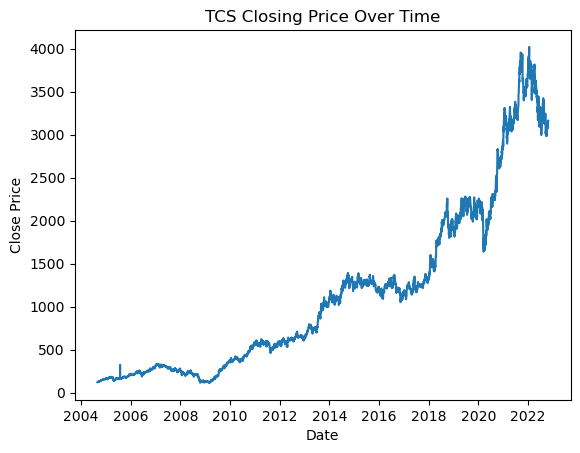

In [5]:
# Closing Price Over Time
plt.figure()
plt.plot(df["Close"])
plt.title("TCS Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

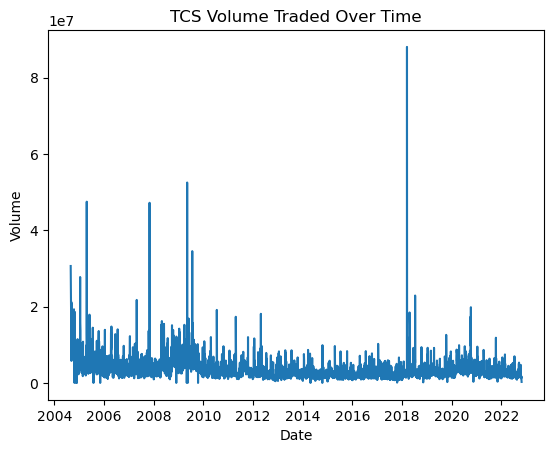

In [6]:
# Volume Over Time
plt.figure()
plt.plot(df["Volume"])
plt.title("TCS Volume Traded Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

In [7]:
# 4. Prepare Data for Prediction
# Predict next day's closing price
df["Prediction"] = df["Close"].shift(-5)
# Drop missing values
df = df.dropna()
# Features and Target
X = df[["Open", "High", "Low", "Volume"]]
y = df["Prediction"]
# Train-Test Split (NO shuffle for time-series)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [8]:
# 5. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
# 6. Make Predictions
predictions = model.predict(X_test)

In [10]:
# 7. Evaluate Model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 9197.406887260462
R2 Score: 0.9778818209088393


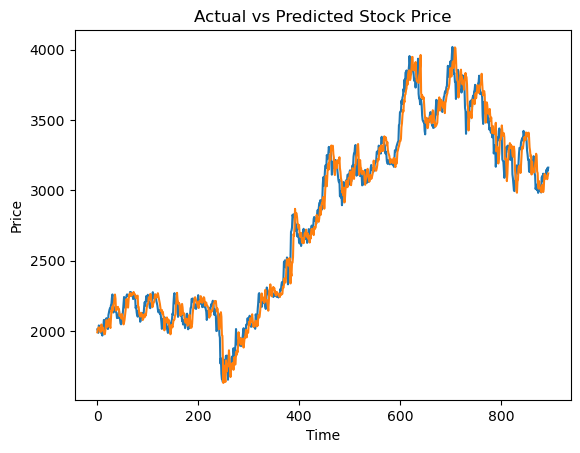

In [11]:
# 8. Actual vs Predicted Graph
plt.figure()
plt.plot(y_test.values)
plt.plot(predictions)
plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

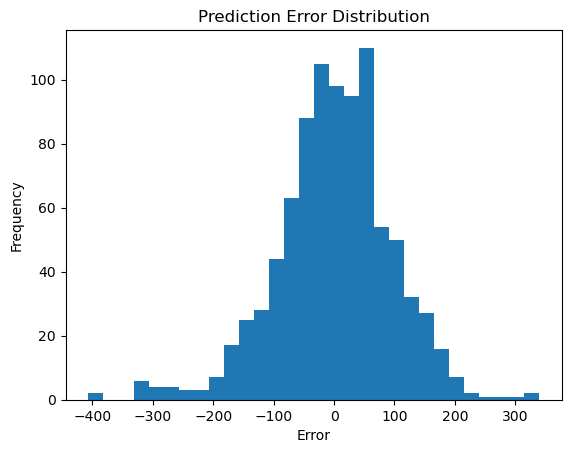

In [12]:
# 9. Error Distribution
errors = y_test.values - predictions
plt.figure()
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()